In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('/Users/mahekdharod/Desktop/interpretable-nlp-sexism-detection/data/edos_labelled_aggregated.csv')
df.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-9609,"In Nigeria, if you rape a woman, the men rape ...",not sexist,none,none,dev
1,sexism2022_english-16993,"Then, she's a keeper. 😉",not sexist,none,none,train
2,sexism2022_english-13149,This is like the Metallica video where the poo...,not sexist,none,none,train
3,sexism2022_english-13021,woman?,not sexist,none,none,train
4,sexism2022_english-966,I bet she wished she had a gun,not sexist,none,none,dev


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(20000, 6)
rewire_id         str
text              str
label_sexist      str
label_category    str
label_vector      str
split             str
dtype: object
rewire_id         0
text              0
label_sexist      0
label_category    0
label_vector      0
split             0
dtype: int64


In [4]:
print("Task A - Sexist vs Not Sexist(Binary classifcation):")
print(df['label_sexist'].value_counts())

print("\nTask B - Category:")
print(df['label_category'].value_counts())

print("\nTask C - Vector:")
print(df['label_vector'].value_counts())

print("\nSplit distribution:")
print(df['split'].value_counts())

Task A - Sexist vs Not Sexist(Binary classifcation):
label_sexist
not sexist    15146
sexist         4854
Name: count, dtype: int64

Task B - Category:
label_category
none                                        15146
2. derogation                                2271
3. animosity                                 1665
4. prejudiced discussions                     475
1. threats, plans to harm and incitement      443
Name: count, dtype: int64

Task C - Vector:
label_vector
none                                                               15146
2.1 descriptive attacks                                             1024
2.2 aggressive and emotive attacks                                   961
3.1 casual use of gendered slurs, profanities, and insults           910
3.2 immutable gender differences and gender stereotypes              596
4.2 supporting systemic discrimination against women as a group      368
1.2 incitement and encouragement of harm                             363
2.3 dehumanisin

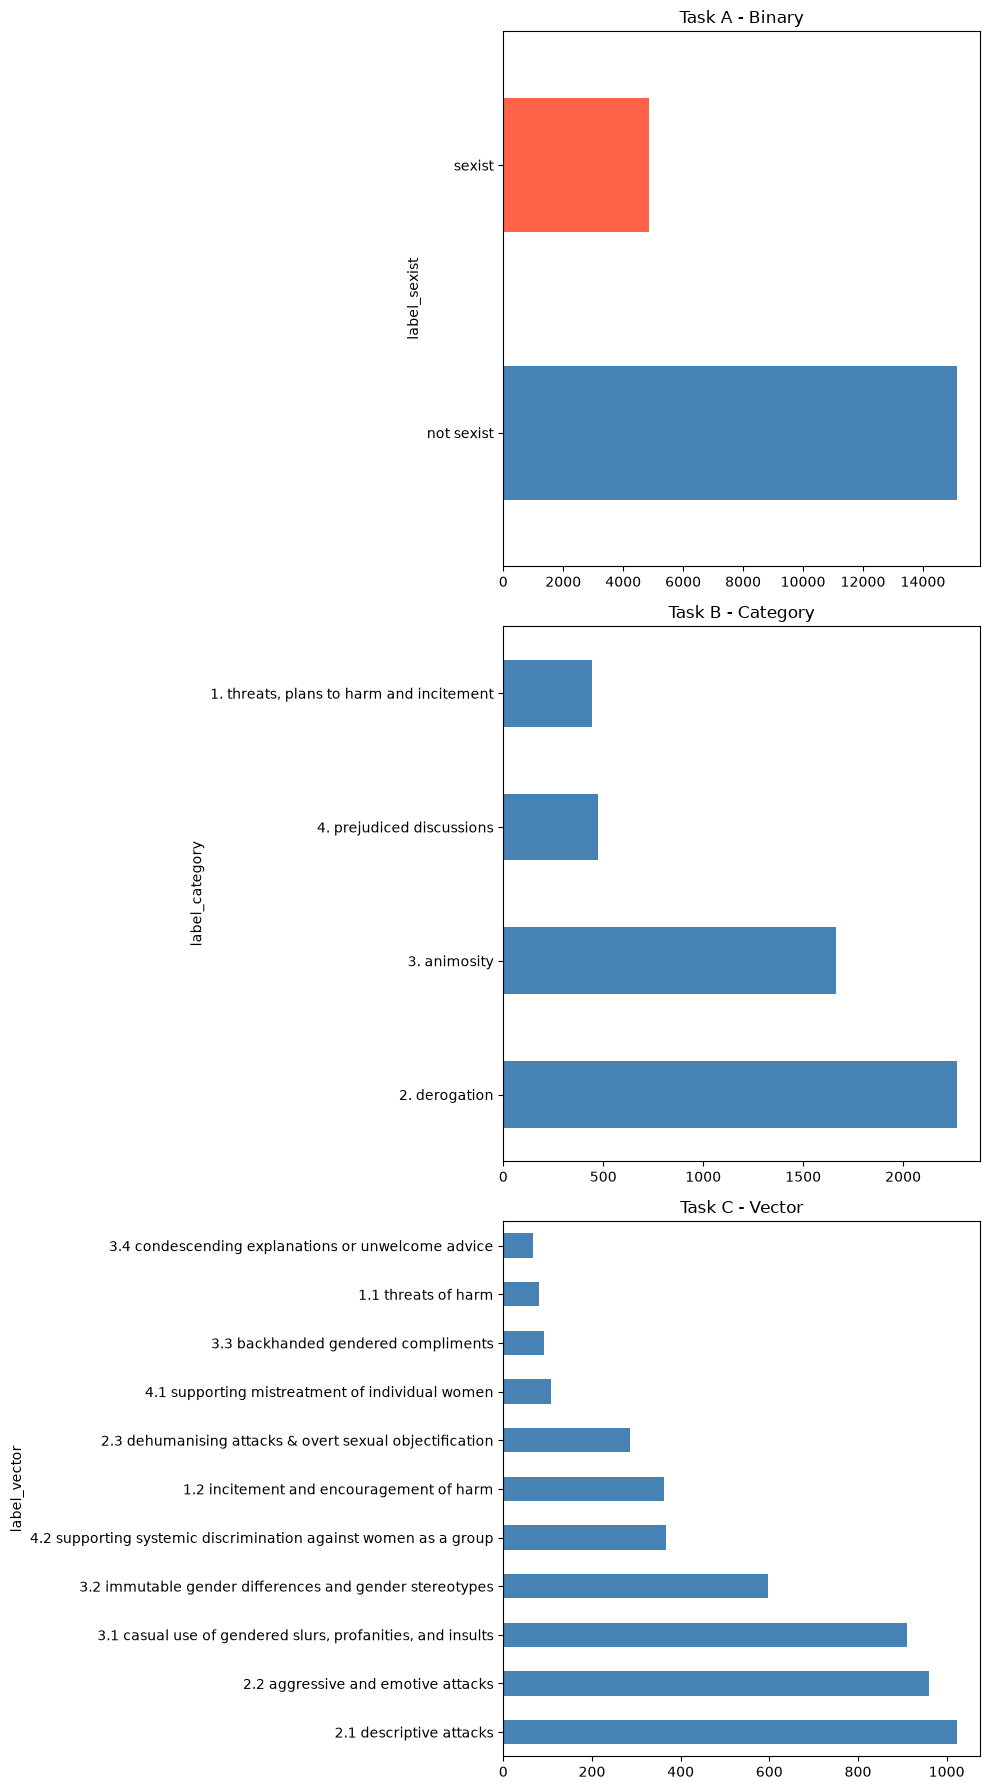

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

df['label_sexist'].value_counts().plot(kind='barh', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Task A - Binary')

df[df['label_category'] != 'none']['label_category'].value_counts().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Task B - Category')

df[df['label_vector'] != 'none']['label_vector'].value_counts().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Task C - Vector')

plt.tight_layout()
plt.show()

### Text length distribution

Justifies `max_length=128` used in `src/data.py`/training, and checks whether sexist posts are systematically longer or shorter than non-sexist ones.

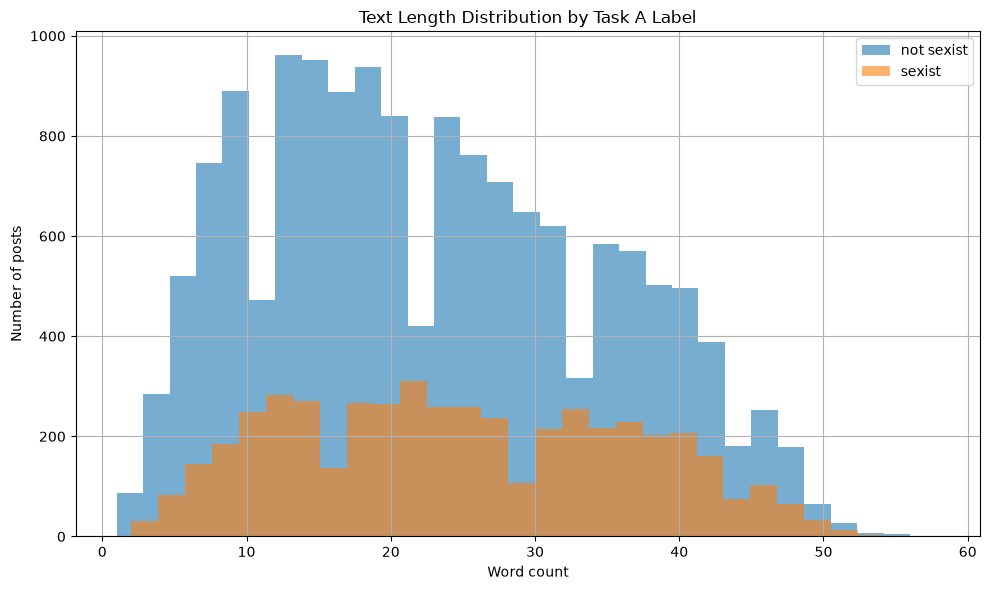

,count,mean,std,min,25%,50%,75%,max
label_sexist,,,,,,,,
not sexist,15146.0,22.794203,11.684816,1.0,13.0,21.0,32.0,56.0
sexist,4854.0,24.917800,11.642949,2.0,15.0,24.0,34.0,58.0


In [6]:
df['word_count'] = df['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 6))
df[df['label_sexist'] == 'not sexist']['word_count'].hist(bins=30, alpha=0.6, label='not sexist', ax=ax)
df[df['label_sexist'] == 'sexist']['word_count'].hist(bins=30, alpha=0.6, label='sexist', ax=ax)
ax.set_xlabel('Word count')
ax.set_ylabel('Number of posts')
ax.set_title('Text Length Distribution by Task A Label')
ax.legend()
plt.tight_layout()
plt.show()

df.groupby('label_sexist')['word_count'].describe()

### Train/dev/test stratification check

The proposal states the official splits are used "without modification" for comparability with published results. This confirms class proportions are actually consistent across the three splits, rather than just asserting it.

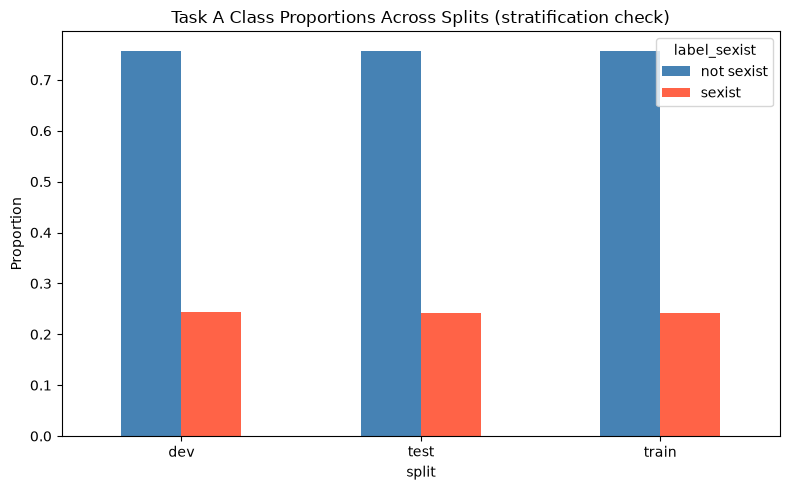

label_sexist,not sexist,sexist
split,,
dev,0.757000,0.243000
test,0.757500,0.242500
train,0.757286,0.242714


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
split_props = df.groupby('split')['label_sexist'].value_counts(normalize=True).unstack()
split_props.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_ylabel('Proportion')
ax.set_title('Task A Class Proportions Across Splits (stratification check)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

split_props

### Task B -> Task C hierarchy

Shows how each Task B category decomposes into Task C's fine-grained vectors in one figure -- a visual for the point (cited from Goldzycher in the lit review) that the three EDOS levels carry shared signal, not independent labels.

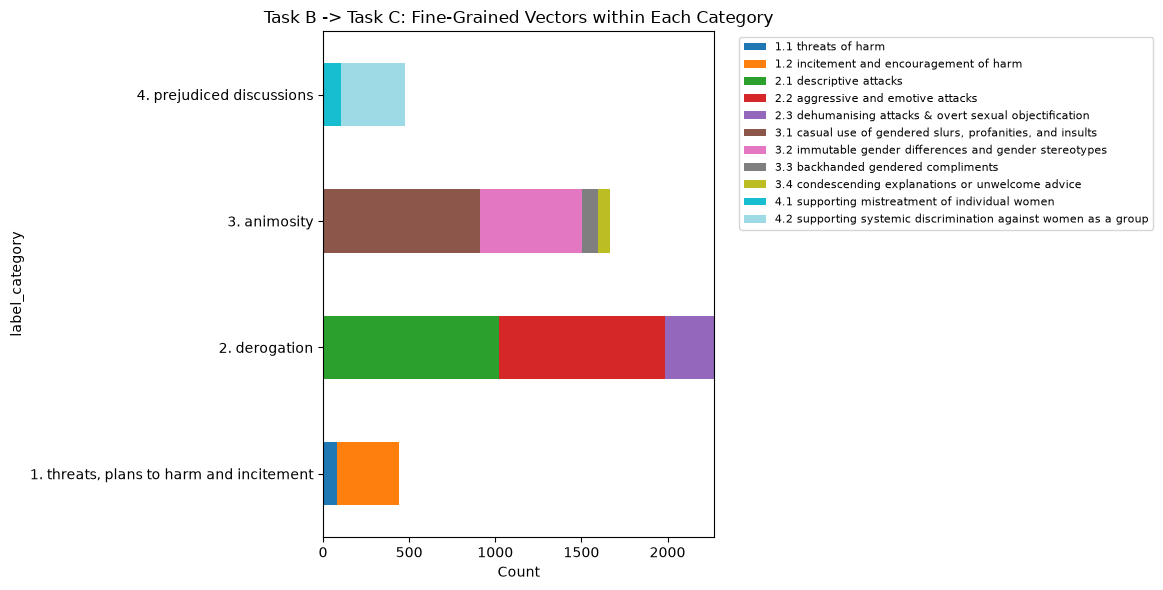

In [9]:
pivot = df[df['label_vector'] != 'none'].groupby(['label_category', 'label_vector']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Count')
ax.set_title('Task B -> Task C: Fine-Grained Vectors within Each Category')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Top words: sexist vs. not sexist

Simple frequency comparison, purely descriptive/exploratory. This is a separate, throwaway view just to see which words are most distinctive per class, and sets up a comparison point for Section 3 of `03_explainability.ipynb`: do LIME/SHAP actually attribute predictions to these same words, or something less obvious?

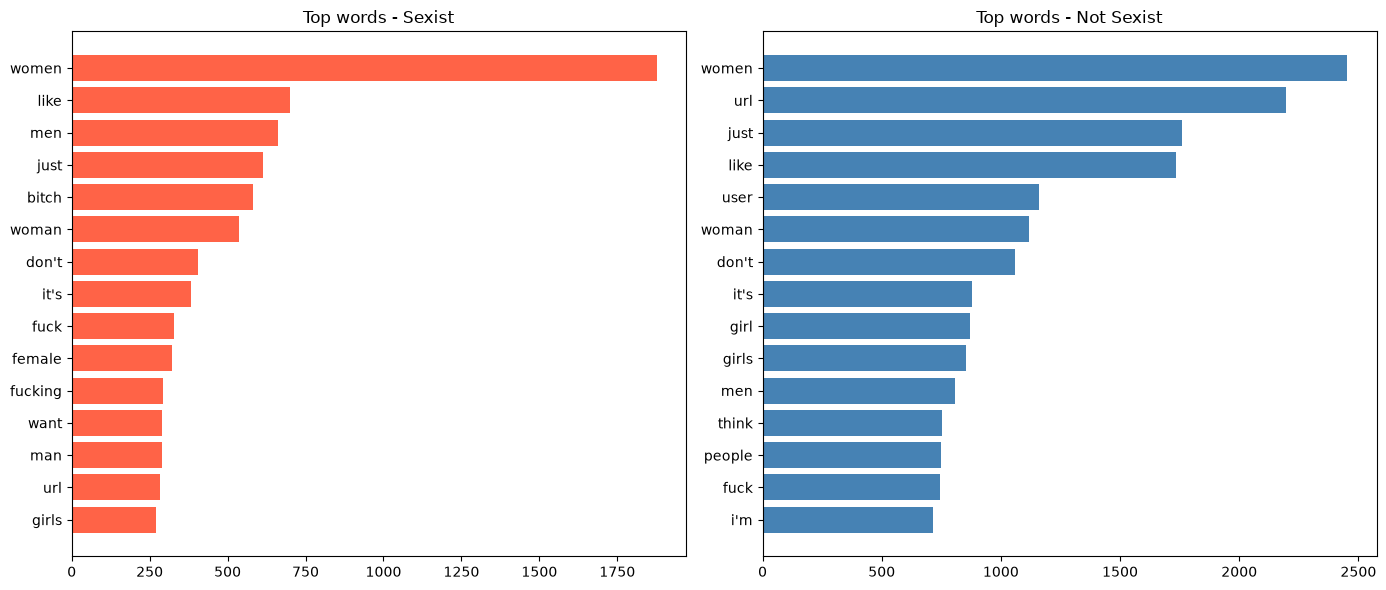

In [10]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def top_words(texts, n=15):
    words = []
    for t in texts:
        words.extend(re.findall(r"[a-zA-Z']+", t.lower()))
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return Counter(words).most_common(n)

sexist_top = top_words(df[df['label_sexist'] == 'sexist']['text'])
not_sexist_top = top_words(df[df['label_sexist'] == 'not sexist']['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([w for w, _ in sexist_top][::-1], [c for _, c in sexist_top][::-1], color='tomato')
axes[0].set_title('Top words - Sexist')
axes[1].barh([w for w, _ in not_sexist_top][::-1], [c for _, c in not_sexist_top][::-1], color='steelblue')
axes[1].set_title('Top words - Not Sexist')
plt.tight_layout()
plt.show()

### Annotator disagreement by Task C category

Uses `data/edos_labelled_individual_annotations.csv` (3 annotators per post, previously unused). For each post, checks whether all 3 annotators gave the same `label_vector`, then aggregates the full-agreement rate per category. This is the same kind of analysis as Table 1 in the ACL-2025 paper cited in the lit review (closely related categories like "descriptive attacks" vs. "aggressive/emotive attacks" should show low agreement) -- except computed on this data directly, so it's original analysis, not just a cited figure.

Task A full agreement rate: 77.8%


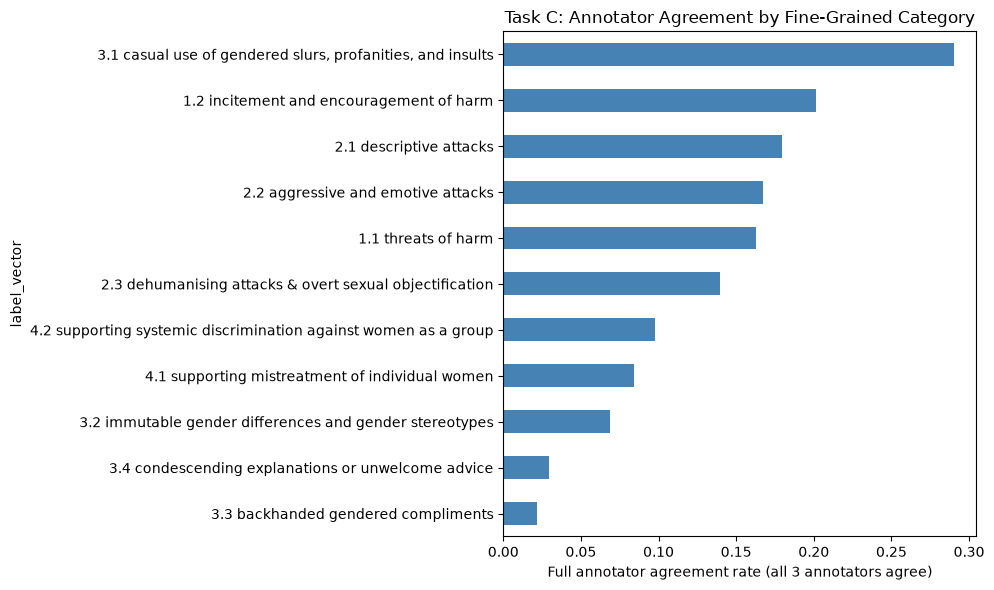

label_vector
3.3 backhanded gendered compliments                                0.021978
3.4 condescending explanations or unwelcome advice                 0.029412
3.2 immutable gender differences and gender stereotypes            0.068792
4.1 supporting mistreatment of individual women                    0.084112
4.2 supporting systemic discrimination against women as a group    0.097826
2.3 dehumanising attacks & overt sexual objectification            0.139860
1.1 threats of harm                                                0.162500
2.2 aggressive and emotive attacks                                 0.167534
2.1 descriptive attacks                                            0.179688
1.2 incitement and encouragement of harm                           0.201102
3.1 casual use of gendered slurs, profanities, and insults         0.290110
Name: full_agreement, dtype: float64

In [11]:
individual_df = pd.read_csv('/Users/mahekdharod/Desktop/interpretable-nlp-sexism-detection/data/edos_labelled_individual_annotations.csv')

# Task A: what fraction of posts have all 3 annotators agreeing on label_sexist?
n_unique_sexist = individual_df.groupby('rewire_id')['label_sexist'].nunique()
print(f"Task A full agreement rate: {(n_unique_sexist == 1).mean():.1%}")

# Task C: agreement rate per fine-grained category (grouped by the aggregated label)
n_unique_vector = individual_df.groupby('rewire_id')['label_vector'].nunique()
agreement_df = df[['rewire_id', 'label_vector']].merge(
    n_unique_vector.rename('n_unique').reset_index(), on='rewire_id'
)
agreement_df['full_agreement'] = agreement_df['n_unique'] == 1

cat_agreement = (
    agreement_df[agreement_df['label_vector'] != 'none']
    .groupby('label_vector')['full_agreement']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
cat_agreement.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Full annotator agreement rate (all 3 annotators agree)')
ax.set_title('Task C: Annotator Agreement by Fine-Grained Category')
plt.tight_layout()
plt.show()

cat_agreement

## 2. Pre-Processing

### Why minimal preprocessing?

Text is **not** lowercased, lemmatised, or stripped of stopwords. RoBERTa's tokenizer is case-sensitive, and preserving the original surface form matters for the LIME/SHAP explanations in `03_explainability.ipynb`. URLs and usernames are already normalised to `[URL]`/`[USER]` by the EDOS dataset creators, so no further cleaning is applied there. This logic mirrors `src/data.py` in the repo (inlined here so this notebook doesn't need the repo cloned).

In [12]:
TASK_LABELS = {
    "A": ["not sexist", "sexist"],
    "B": [
        "1. threats, plans to harm and incitement",
        "2. derogation",
        "3. animosity",
        "4. prejudiced discussions",
    ],
    "C": [
        "1.1 threats of harm",
        "1.2 incitement and encouragement of harm",
        "2.1 descriptive attacks",
        "2.2 aggressive and emotive attacks",
        "2.3 dehumanising attacks & overt sexual objectification",
        "3.1 casual use of gendered slurs, profanities, and insults",
        "3.2 immutable gender differences and gender stereotypes",
        "3.3 backhanded gendered compliments",
        "3.4 condescending explanations or unwelcome advice",
        "4.1 supporting mistreatment of individual women",
        "4.2 supporting systemic discrimination against women as a group",
    ],
}
LABEL_COLUMNS = {"A": "label_sexist", "B": "label_category", "C": "label_vector"}

def build_task_frame(df, task):
    out = df.copy()
    if task in ("B", "C"):
        out = out[out["label_sexist"] == "sexist"].copy()
    label_col = LABEL_COLUMNS[task]
    labels = TASK_LABELS[task]
    label2id = {label: i for i, label in enumerate(labels)}
    out = out[out[label_col].isin(labels)].copy()
    out["label_id"] = out[label_col].map(label2id).astype(int)
    return out[["text", "label_id", "split"]].reset_index(drop=True)

def get_splits(task_df):
    train = task_df[task_df["split"] == "train"].reset_index(drop=True)
    dev = task_df[task_df["split"] == "dev"].reset_index(drop=True)
    test = task_df[task_df["split"] == "test"].reset_index(drop=True)
    return train, dev, test

task_df = build_task_frame(df, "A")
train_df, dev_df, test_df = get_splits(task_df)
print(f"Task A: train={len(train_df)} dev={len(dev_df)} test={len(test_df)}")
train_df.head()

Task A: train=14000 dev=2000 test=4000


,text,label_id,split
0,"Then, she's a keeper. 😉",0,train
1,This is like the Metallica video where the poo...,0,train
2,woman?,0,train
3,Unlicensed day care worker reportedly tells co...,0,train
4,[USER] Leg day is easy. Hot girls who wear min...,1,train


In [13]:
import os

# Running locally (not Colab), so this is real, permanent persistence --
# no Drive mount needed. Writes one train/dev/test CSV triple per task
# to data/processed/. This mirrors src.data.save_task_splits(); inlined
# here since this notebook doesn't import from the repo's src/ package.
REPO_ROOT = "/Users/mahekdharod/Desktop/interpretable-nlp-sexism-detection"

def save_task_splits(train_df, dev_df, test_df, task, out_dir=None):
    out_dir = out_dir or os.path.join(REPO_ROOT, "data/processed")
    os.makedirs(out_dir, exist_ok=True)
    train_df.to_csv(os.path.join(out_dir, f"task_{task}_train.csv"), index=False)
    dev_df.to_csv(os.path.join(out_dir, f"task_{task}_dev.csv"), index=False)
    test_df.to_csv(os.path.join(out_dir, f"task_{task}_test.csv"), index=False)
    print(f"Saved task {task} splits ({len(train_df)} train, {len(dev_df)} dev, {len(test_df)} test)")

for task in ["A", "B", "C"]:
    t_df = build_task_frame(df, task)
    tr, dv, te = get_splits(t_df)
    save_task_splits(tr, dv, te, task)

print(f"\nSaved to {os.path.join(REPO_ROOT, 'data/processed')}/ -- 9 CSVs total (3 tasks x train/dev/test)")

Saved task A splits (14000 train, 2000 dev, 4000 test)
Saved task B splits (3398 train, 486 dev, 970 test)
Saved task C splits (3398 train, 486 dev, 970 test)

Saved to /Users/mahekdharod/Desktop/interpretable-nlp-sexism-detection/data/processed/ -- 9 CSVs total (3 tasks x train/dev/test)


In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
sample_text = train_df["text"].iloc[0]
tokens = tokenizer.tokenize(sample_text)

print("Original text:", sample_text)
print("\nTokens (case preserved, [URL]/[USER] kept as-is):")
print(tokens)
print(f"\nToken count: {len(tokens)} (max_length=128 used in training)")

Original text: Then, she's a keeper. 😉

Tokens (case preserved, [URL]/[USER] kept as-is):
['Then', ',', 'Ġshe', "'s", 'Ġa', 'Ġkeeper', '.', 'ĠðŁĺ', 'ī']

Token count: 9 (max_length=128 used in training)
